In [71]:
batch_size = 32

In [72]:
import os
import sys
import pickle

cur_dir = os.getcwd()
par_dir = os.path.join(cur_dir, '..')
sys.path.append(par_dir)


root = os.path.join(par_dir, 'data_tensor_cache')
save_dir = os.path.join(cur_dir, 'explainer_checkpoints', 'real')
best_model_path = os.path.join(save_dir, 'PGExplainer_GINGRU_ 0.6189.pth')
edge_mask_mean_save_path = os.path.join(save_dir, 'PGExplainer_GINGRU_edge_mask_mean_all.pickle')
mi_dict_path = os.path.join(root, 'data', 'mi_dict_static.pickle')


with open(edge_mask_mean_save_path, 'rb') as f:
    edge_mask_mean = pickle.load(f)

In [73]:
from teds_tensor_dataset import TEDSTensorDataset
from utils.processing_utils import mi_edge_index_batched, train_test_split_customed_dataset, train_test_split_customed

dataset = TEDSTensorDataset(root)
col_list, col_dims, ad_col_index, dis_col_index = dataset.col_info
edge_index_single = mi_edge_index_batched(batch_size=1, num_nodes=60, mi_dict_path=mi_dict_path)



/opt/miniconda3/envs/pyg_2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


저장되어 있는 전처리된 데이터가 있습니다. 해당 데이터를 불러오는 중..
불러오기 완료


In [74]:
train_dataset, val_dataset, test_dataset = train_test_split_customed_dataset(dataset=dataset)

dataset = val_dataset
train_loader, explainer_loader, test_loader = train_test_split_customed(dataset=dataset,
                                                                  batch_size=batch_size)


Train Set Size: 975896
Valid Set Size: 209119
Test Set Size: 209123
Train Set Size: 146383
Valid Set Size: 31366
Test Set Size: 31370


In [75]:
edge_mask_mean

tensor([0.3486, 0.3388, 0.3313, 0.3188, 0.3304, 0.3509, 0.3410, 0.3270, 0.3156,
        0.3454, 0.3759, 0.3339, 0.3664, 0.3837, 0.3393, 0.3842, 0.3616, 0.3259,
        0.3534, 0.3258, 0.3482, 0.3192, 0.3647, 0.3765, 0.3787, 0.3310, 0.3431,
        0.3158, 0.3395, 0.3469, 0.3445, 0.3531, 0.3453, 0.3826, 0.3439, 0.3450,
        0.3287, 0.3212, 0.3398, 0.3347, 0.3500, 0.3330, 0.3390, 0.3140, 0.3454,
        0.3337, 0.3552, 0.3668, 0.3279, 0.3353, 0.3216, 0.3374, 0.3418, 0.3197,
        0.3399, 0.3269, 0.3462, 0.3487, 0.3217, 0.3198, 0.3122, 0.2951, 0.3197,
        0.3067, 0.3072, 0.3325, 0.3523, 0.3429, 0.3831, 0.3577, 0.3600, 0.3676,
        0.3309, 0.3345, 0.3099, 0.3694, 0.3295, 0.3161, 0.3164, 0.3221, 0.3470,
        0.3530, 0.3489, 0.3750, 0.3921, 0.3480, 0.3333, 0.3335, 0.3446, 0.3367,
        0.3453, 0.3584, 0.3485, 0.3525, 0.3285, 0.3446, 0.3550, 0.3210, 0.3487,
        0.3280, 0.3341, 0.3640, 0.3833, 0.3535, 0.4121, 0.3795, 0.4107, 0.3983,
        0.3185, 0.2952, 0.3158, 0.2990, 

In [76]:
edge_index_single

tensor([[  0,   0,   0,  ..., 119, 119, 119],
        [  1,   2,   3,  ..., 114, 115, 116]])

In [77]:
ad_var_list = [col_list[i] for i in ad_col_index]
ad_node_dict = {var: 0.0 for var in ad_var_list}

dis_var_list = [col_list[i] for i in dis_col_index]
dis_node_dict = {var: 0.0 for var in dis_var_list}

In [78]:
ad_edge_index = edge_index_single[:, :476]
dis_edge_index = edge_index_single[:, 476:] - 60

In [79]:
for i in range(ad_edge_index.shape[1]):
    src = ad_edge_index[:, i][0].item()
    tar = ad_edge_index[:, i][1].item()
    edge_mask_idx = i
    edge_importance = edge_mask_mean[edge_mask_idx].item()

    src_var_name = ad_var_list[src]
    tar_var_name = ad_var_list[tar]

    print(f"{src_var_name} -> {tar_var_name}:   {edge_importance}")
    ad_node_dict[src_var_name] += edge_importance
    ad_node_dict[tar_var_name] += edge_importance

STFIPS -> EDUC:   0.34861141443252563
STFIPS -> MARSTAT:   0.33882594108581543
STFIPS -> SERVICES:   0.33130934834480286
STFIPS -> PSOURCE:   0.31876304745674133
STFIPS -> ARRESTS:   0.3303503096103668
STFIPS -> EMPLOY:   0.35092735290527344
STFIPS -> METHUSE:   0.34096696972846985
STFIPS -> PSYPROB:   0.3270114064216614
STFIPS -> VET:   0.31557321548461914
STFIPS -> LIVARAG:   0.3454419672489166
STFIPS -> DAYWAIT:   0.3758770227432251
STFIPS -> DSMCRIT:   0.33391451835632324
STFIPS -> DETNLF:   0.3664029836654663
STFIPS -> PRIMINC:   0.383696973323822
STFIPS -> SUB1:   0.33932098746299744
STFIPS -> SUB2:   0.3842194974422455
STFIPS -> SUB3:   0.36164382100105286
STFIPS -> ROUTE1:   0.3259434103965759
STFIPS -> ROUTE3:   0.35343873500823975
STFIPS -> FREQ1:   0.32580244541168213
STFIPS -> FREQ3:   0.34817278385162354
STFIPS -> FRSTUSE1:   0.3191913664340973
STFIPS -> FRSTUSE3:   0.36466583609580994
STFIPS -> HLTHINS:   0.3764735758304596
STFIPS -> PRIMPAY:   0.3787270486354828
STFIPS -

In [80]:
for i in range(dis_edge_index.shape[1]):
    src = dis_edge_index[:, i][0].item()
    tar = dis_edge_index[:, i][1].item()
    edge_mask_idx = i + 476
    edge_importance = edge_mask_mean[edge_mask_idx].item()

    src_var_name = dis_var_list[src]
    tar_var_name = dis_var_list[tar]

    print(f"{src_var_name} -> {tar_var_name}:   {edge_importance}")
    dis_node_dict[src_var_name] += edge_importance
    dis_node_dict[tar_var_name] += edge_importance
    

STFIPS -> EDUC:   0.348644882440567
STFIPS -> MARSTAT:   0.33889564871788025
STFIPS -> SERVICES_D:   0.33140474557876587
STFIPS -> PSOURCE:   0.3186899721622467
STFIPS -> ARRESTS_D:   0.3302890658378601
STFIPS -> EMPLOY_D:   0.35094350576400757
STFIPS -> METHUSE:   0.3410080373287201
STFIPS -> PSYPROB:   0.32713112235069275
STFIPS -> VET:   0.3155313730239868
STFIPS -> LIVARAG_D:   0.34544920921325684
STFIPS -> DAYWAIT:   0.3759588599205017
STFIPS -> DSMCRIT:   0.33409032225608826
STFIPS -> DETNLF_D:   0.3665124177932739
STFIPS -> PRIMINC:   0.38374966382980347
STFIPS -> SUB1_D:   0.3394160568714142
STFIPS -> SUB2_D:   0.38454222679138184
STFIPS -> SUB3_D:   0.36191824078559875
STFIPS -> ROUTE1:   0.32599008083343506
STFIPS -> ROUTE3:   0.3536531329154968
STFIPS -> FREQ1_D:   0.3258357644081116
STFIPS -> FREQ3_D:   0.34839755296707153
STFIPS -> FRSTUSE1:   0.31925109028816223
STFIPS -> FRSTUSE3:   0.3649166226387024
STFIPS -> HLTHINS:   0.3764825761318207
STFIPS -> PRIMPAY:   0.3787518

In [81]:
ad_node_dict

{'STFIPS': 20.715146481990814,
 'EDUC': 5.555508852005005,
 'MARSTAT': 4.7085272669792175,
 'SERVICES': 5.423175126314163,
 'DETCRIM': 3.352080315351486,
 'PSOURCE': 5.0161134004592896,
 'NOPRIOR': 4.3322687447071075,
 'ARRESTS': 5.260446548461914,
 'EMPLOY': 5.680198580026627,
 'METHUSE': 4.155249863862991,
 'PSYPROB': 4.710717678070068,
 'PREG': 3.7858684360980988,
 'GENDER': 1.6198460757732391,
 'VET': 3.6354997754096985,
 'LIVARAG': 4.076475650072098,
 'DAYWAIT': 4.564172774553299,
 'DSMCRIT': 8.75636026263237,
 'AGE': 4.3037877678871155,
 'RACE': 3.243017315864563,
 'ETHNIC': 3.2724655270576477,
 'DETNLF': 5.208483278751373,
 'PRIMINC': 5.471105724573135,
 'SUB1': 21.596668362617493,
 'SUB2': 13.881404221057892,
 'SUB3': 9.056434392929077,
 'ROUTE1': 11.638909101486206,
 'ROUTE2': 7.342949777841568,
 'ROUTE3': 5.060378760099411,
 'FREQ1': 10.320801794528961,
 'FREQ2': 7.169366866350174,
 'FREQ3': 5.068872004747391,
 'FRSTUSE1': 6.935225248336792,
 'FRSTUSE2': 6.528102457523346,
 '

In [82]:
dis_node_dict

{'STFIPS': 20.720250457525253,
 'EDUC': 5.5556846261024475,
 'MARSTAT': 4.7088340520858765,
 'SERVICES_D': 5.42525377869606,
 'DETCRIM': 3.3513470888137817,
 'PSOURCE': 5.0143336951732635,
 'NOPRIOR': 4.334141343832016,
 'ARRESTS_D': 5.25928720831871,
 'EMPLOY_D': 5.680207341909409,
 'METHUSE': 4.156002849340439,
 'PSYPROB': 4.712606966495514,
 'PREG': 3.787498563528061,
 'GENDER': 1.620336264371872,
 'VET': 3.63478821516037,
 'LIVARAG_D': 4.076415449380875,
 'DAYWAIT': 4.56447896361351,
 'DSMCRIT': 8.761298298835754,
 'AGE': 4.305472671985626,
 'RACE': 3.2434686720371246,
 'ETHNIC': 3.2731372714042664,
 'DETNLF_D': 5.20955103635788,
 'PRIMINC': 5.471309274435043,
 'SUB1_D': 21.604073733091354,
 'SUB2_D': 13.893990576267242,
 'SUB3_D': 9.061064064502716,
 'ROUTE1': 11.63982880115509,
 'ROUTE2': 7.352093607187271,
 'ROUTE3': 5.062526822090149,
 'FREQ1_D': 10.321152418851852,
 'FREQ2_D': 7.1774027943611145,
 'FREQ3_D': 5.071223974227905,
 'FRSTUSE1': 6.93669980764389,
 'FRSTUSE2': 6.5353

In [83]:
import pandas as pd

ad_node_importance = pd.Series(ad_node_dict)
dis_node_importance = pd.Series(dis_node_dict)

In [84]:
ad_node_importance.sort_values(ascending=False)

SUB1                   21.596668
STFIPS                 20.715146
CBSA2020               19.393312
DIVISION               13.996390
SUB2                   13.881404
ALCDRUG                11.770268
ROUTE1                 11.638909
FREQ1                  10.320802
SUB3                    9.056434
DSMCRIT                 8.756360
ROUTE2                  7.342950
FREQ2                   7.169367
FRSTUSE1                6.935225
FRSTUSE2                6.528102
IDU                     6.110468
EMPLOY                  5.680199
REGION                  5.627562
EDUC                    5.555509
PRIMINC                 5.471106
PRIMPAY                 5.442629
SERVICES                5.423175
FREQ_ATND_SELF_HELP     5.323122
ARRESTS                 5.260447
FRSTUSE3                5.237112
DETNLF                  5.208483
FREQ3                   5.068872
ROUTE3                  5.060379
HERFLG                  5.029437
PSOURCE                 5.016113
COKEFLG                 4.938118
MARFLG    

In [101]:
ad_node_importance.to_csv('PGExplainer_node_importance_admission.csv')
dis_node_importance.to_csv('PGExplainer_node_importance_discharge.csv')

In [85]:
dis_node_importance.sort_values(ascending=False)

SUB1_D                   21.604074
STFIPS                   20.720250
CBSA2020                 19.400694
DIVISION                 14.001421
SUB2_D                   13.893991
ALCDRUG                  11.781108
ROUTE1                   11.639829
FREQ1_D                  10.321152
SUB3_D                    9.061064
DSMCRIT                   8.761298
ROUTE2                    7.352094
FREQ2_D                   7.177403
FRSTUSE1                  6.936700
FRSTUSE2                  6.535378
IDU                       6.113472
EMPLOY_D                  5.680207
REGION                    5.627375
EDUC                      5.555685
PRIMINC                   5.471309
PRIMPAY                   5.442662
SERVICES_D                5.425254
FREQ_ATND_SELF_HELP_D     5.323104
ARRESTS_D                 5.259287
FRSTUSE3                  5.239774
DETNLF_D                  5.209551
FREQ3_D                   5.071224
ROUTE3                    5.062527
HERFLG                    5.031632
PSOURCE             

In [86]:
ad_node_importance_copy = ad_node_importance.copy()
dis_node_importance_copy = dis_node_importance.copy()

change = []
flag = {}
for col in dis_node_importance_copy.index:
    if '_D' in col:
        change.append(col)
        flag[col] = True
    else:
        flag[col] = False

dis_ = pd.concat([dis_node_importance_copy, pd.Series(flag)], axis=1)
dis_.index = ad_node_importance_copy.index

node_importances = pd.concat([ad_node_importance_copy, dis_], axis=1)
node_importances.columns = ['admission', 'discharge', 'flag']
node_importances['mean'] = (node_importances['admission'] + node_importances['discharge']) / 2
node_importances.sort_values(by=['mean'], ascending=False)

,admission,discharge,flag,mean
SUB1,21.596668,21.604074,True,21.600371
STFIPS,20.715146,20.720250,False,20.717698
CBSA2020,19.393312,19.400694,False,19.397003
DIVISION,13.996390,14.001421,False,13.998905
SUB2,13.881404,13.893991,True,13.887697
ALCDRUG,11.770268,11.781108,False,11.775688
ROUTE1,11.638909,11.639829,False,11.639369
FREQ1,10.320802,10.321152,True,10.320977
SUB3,9.056434,9.061064,True,9.058749
DSMCRIT,8.756360,8.761298,False,8.758829


MI와의 연관성

In [87]:
import pickle
with open(mi_dict_path, 'rb') as f:
    mi_dict = pickle.load(f)
node_imp_mi = {}
for var in mi_dict.keys():
    sum_mi = float(mi_dict[var].sum())
    node_imp_mi[var] = sum_mi
node_imp_mi = pd.Series(node_imp_mi)
node_imp_mi.sort_values(ascending=False)


STFIPS                 18.798848
CBSA2020               13.398431
DIVISION               11.898664
SUB1                   10.944678
ALCDRUG                 9.566697
ROUTE1                  8.728401
REGION                  7.372430
SUB2                    7.304347
IDU                     6.935677
FREQ1                   6.846690
FRSTUSE1                6.649816
ROUTE2                  6.237405
EMPLOY                  6.153507
PSOURCE                 6.042126
SUB3                    5.945813
FREQ2                   5.932237
FRSTUSE2                5.790147
ROUTE3                  5.607081
FREQ3                   5.587880
DSMCRIT                 5.578176
LIVARAG                 5.493563
FRSTUSE3                5.492137
EDUC                    5.388139
PRIMPAY                 5.330549
HLTHINS                 4.354037
VET                     4.326367
FREQ_ATND_SELF_HELP     4.250745
ARRESTS                 4.239655
PRIMINC                 3.296966
MARSTAT                 2.922252
DETNLF    

LOS별로 분류 후 Explain

In [88]:
import pandas as pd
import os
import torch
raw_data = os.path.join(root, 'raw', 'missing_corrected.csv')
raw_df = pd.read_csv(raw_data)
raw_df[raw_df["LOS"] == 1]

,STFIPS,EDUC,MARSTAT,SERVICES,DETCRIM,LOS,PSOURCE,NOPRIOR,ARRESTS,EMPLOY,...,SEDHPFLG,INHFLG,OTCFLG,OTHERFLG,DIVISION,REGION,IDU,ALCDRUG,CBSA2020,REASONb
1,51,3,-9,7,0,1,6,0,0,4,...,0,0,0,0,5,3,1,3,-9,0
12,2,3,1,6,0,1,6,0,0,1,...,0,0,0,0,9,4,0,3,-9,0
249,2,2,1,5,0,1,1,0,0,3,...,0,0,0,0,9,4,1,2,21820,0
260,2,2,1,7,0,1,-9,0,0,4,...,0,0,0,1,9,4,0,3,-9,0
357,2,3,4,2,0,1,1,1,0,3,...,0,0,0,1,9,4,0,3,11260,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1393642,56,3,4,7,0,1,1,1,0,1,...,0,0,0,0,8,4,0,1,-9,0
1393667,56,3,1,5,1,1,7,0,0,2,...,0,0,0,0,8,4,1,2,-9,0
1393843,56,3,2,7,1,1,7,1,0,1,...,0,0,0,0,8,4,0,2,-9,1
1393935,56,3,4,7,0,1,1,0,0,1,...,0,0,0,0,8,4,0,2,-9,0


In [89]:
import torch
def separation_by_los(x_tensor, los_tensor, y_tensor, max_los=37):
    los_dict = {}
    for los in range(1, max_los + 1):
        idx = (los_tensor == los).nonzero(as_tuple=True)[0]  # shape: [k]
        los_dict[los] = [x_tensor[idx], y_tensor[idx]]
    return los_dict


from torch.utils.data import Dataset
class SeparatedDatasetByLOS(Dataset):
    def __init__(self, x_tensor, y_tensor, los: int):
        self.x_tensor = x_tensor
        self.y_tensor = y_tensor
        self.los = torch.tensor(los)

    def __getitem__(self, index):
        return self.x_tensor[index], self.y_tensor[index], self.los
    
    def __len__(self):
        return self.x_tensor.size(0)

In [90]:
dataset = TEDSTensorDataset(root)
x_tensor_raw = dataset.processed_tensor[:, :-1]
y_tensor_raw = dataset.processed_tensor[:, -1]
los_tensor_raw = dataset.LOS

저장되어 있는 전처리된 데이터가 있습니다. 해당 데이터를 불러오는 중..
불러오기 완료


In [91]:
seperated_data = separation_by_los(x_tensor_raw, los_tensor_raw, y_tensor_raw)
seperated_data

{1: [tensor([[ 44,   3,   0,  ...,   2,   3,   0],
          [  1,   3,   1,  ...,   1,   3,   0],
          [  1,   2,   1,  ...,   2,   2, 189],
          ...,
          [ 48,   3,   2,  ...,   1,   2,   0],
          [ 48,   3,   4,  ...,   1,   2,   0],
          [ 48,   3,   1,  ...,   1,   1,   0]]),
  tensor([0, 0, 0,  ..., 1, 0, 0])],
 2: [tensor([[ 1,  3,  4,  ...,  1,  3,  0],
          [29,  4,  4,  ...,  1,  2, 18],
          [ 1,  3,  2,  ...,  1,  3, 18],
          ...,
          [48,  3,  1,  ...,  1,  1,  0],
          [48,  2,  1,  ...,  1,  1,  0],
          [11,  4,  4,  ...,  1,  2,  0]]),
  tensor([0, 0, 0,  ..., 0, 0, 0])],
 3: [tensor([[24,  2,  1,  ...,  1,  3, 18],
          [16,  3,  1,  ...,  1,  2, 18],
          [ 1,  2,  2,  ...,  1,  2, 18],
          ...,
          [48,  3,  0,  ...,  2,  2,  0],
          [48,  4,  1,  ...,  1,  2,  0],
          [41,  3,  4,  ...,  1,  2,  0]]),
  tensor([0, 0, 0,  ..., 0, 0, 0])],
 4: [tensor([[ 1,  4,  4,  ...,  1,  

In [92]:
dataset_list = []
for i in range(1, 38):
    x_tensor, y_tensor = seperated_data[i]
    sep_dataset = SeparatedDatasetByLOS(x_tensor, y_tensor, i)
    dataset_list.append(sep_dataset)

In [93]:
from torch.utils.data import DataLoader
loader = DataLoader(dataset_list[0], batch_size=batch_size, drop_last=True)
loader.__iter__()._next_data()

[tensor([[ 44,   3,   0,  ...,   2,   3,   0],
         [  1,   3,   1,  ...,   1,   3,   0],
         [  1,   2,   1,  ...,   2,   2, 189],
         ...,
         [  1,   1,   1,  ...,   2,   3,  18],
         [ 31,   2,   3,  ...,   1,   3,  18],
         [ 21,   3,   2,  ...,   2,   3,  18]]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 0, 0, 0, 0, 0, 0, 0]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1])]

In [94]:
from torch.utils.data import DataLoader
from gingru_PGExplainer import load_pgexplainer, get_mean_edge_mask
from models.gingru_for_explain import GinGruForExplain2
from utils.processing_utils import mi_edge_index_batched
import pickle

edge_index_single = mi_edge_index_batched(batch_size=1,
                                            num_nodes=60,
                                            mi_dict_path=mi_dict_path)
num_edges_single = edge_index_single.shape[1]

def mean_edge_mask_util(dataset, explainer_path, batch_size, save_path):
    loader = DataLoader(dataset, batch_size=batch_size, drop_last=True)
    return get_mean_edge_mask(explainer_path, loader=loader, num_edges_single=num_edges_single, edge_mask_mean_save_path=save_path)

def get_mean_edge_mask_per_los(dataset_list, explainer_path, save_path, batch_size=32):
    
    edge_mask_list = []
    for dataset in dataset_list:
        edge_mask = mean_edge_mask_util(dataset, explainer_path, batch_size, save_path)
        edge_mask_list.append(edge_mask)
    edge_mask = mean_edge_mask_util(dataset_list[24], explainer_path, batch_size, save_path)
    edge_mask_list.append(edge_mask)
    with open(save_path, 'wb') as f:
        pickle.dump(edge_mask_list, f)
    
    return edge_mask_list

'''save_path = os.path.join(save_dir, 'per_los', 'per_los_mean_edge_mask.pickle')
edge_mask_list = get_mean_edge_mask_per_los(dataset_list,
                                            explainer_path=best_model_path,
                                            save_path=save_path)'''

SEED = 2025
저장되어 있는 전처리된 데이터가 있습니다. 해당 데이터를 불러오는 중..
불러오기 완료
Train Set Size: 975896
Valid Set Size: 209119
Test Set Size: 209123
Train Set Size: 146383
Valid Set Size: 31366
Test Set Size: 31370
Loading the best model state...
Loading best model from /Users/jeong-yunseong/Documents/programming/Phase_2/analyze/explainer_checkpoints/real/PGExplainer_GINGRU_ 0.6189.pth...
=== Soft-mask Summary (pooled over 100 batches, 3200 samples) ===
Mode: mask
Mean |Δlogit| per sample:  0.034543
Pooled Original AUC:  0.910801
Pooled Masked   AUC:  0.910688
Pooled AUC Diff     :  0.000113
Loading the best model state...
Loading best model from /Users/jeong-yunseong/Documents/programming/Phase_2/analyze/explainer_checkpoints/real/PGExplainer_GINGRU_ 0.6189.pth...
=== Soft-mask Summary (pooled over 100 batches, 3200 samples) ===
Mode: remove
Mean |Δlogit| per sample:  3.526007
Pooled Original AUC:  0.910801
Pooled Masked   AUC:  0.383070
Pooled AUC Diff     :  0.527730


"save_path = os.path.join(save_dir, 'per_los', 'per_los_mean_edge_mask.pickle')\nedge_mask_list = get_mean_edge_mask_per_los(dataset_list,\n                                            explainer_path=best_model_path,\n                                            save_path=save_path)"

In [95]:
save_path = os.path.join(save_dir, 'per_los', 'per_los_mean_edge_mask.pickle')
with open(save_path, 'rb') as f:
    asdf = pickle.load(f)

In [96]:
asdf[0].shape

torch.Size([952])

In [97]:
edge_index_single = mi_edge_index_batched(
    batch_size=1,
    num_nodes=60,
    mi_dict_path=mi_dict_path
)


In [98]:
import networkx as nx
import matplotlib.pyplot as plt
import re

def draw_star_network(file_path):
    # 1. 파일 데이터 로드 및 파싱
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
        return

    edges = []
    pattern = r"(\w+)\s*->\s*(\w+):\s*([\d.]+)"
    for line in lines:
        match = re.search(pattern, line)
        if match:
            u, v, w = match.groups()
            edges.append((u, v, float(w)))

    # 2. 그래프 생성
    G = nx.DiGraph()
    G.add_weighted_edges_from(edges)

    # 3. 레이아웃 설정 (스타 그래프 형태를 위한 최적화)
    # k 값을 높여서 노드 사이의 거리를 아주 넓게 벌립니다.
    pos = nx.spring_layout(G, k=2, iterations=100, seed=42)

    # 4. 시각화 데이터 준비
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    min_w, max_w = min(weights), max(weights)
    
    # 가중치에 따른 선 굵기 (사용자 참고 코드 스타일 적용)
    # 너무 얇지 않게 기본 굵기를 1로 잡고 가변 폭을 더합니다.
    edge_widths = [(w - min_w) / (max_w - min_w) * 1 for w in weights]

    # 5. 그래프 그리기 (사용자 요청 스타일 반영)
    plt.figure(figsize=(14, 12))
    
    # 노드 그리기: 연한 파랑, 검정 테두리
    nx.draw_networkx_nodes(G, pos, 
                           node_size=1000, 
                           node_color="lightblue", 
                           linewidths=1.2, 
                           edgecolors="black")

    # 엣지 그리기: 화살표 포함, 가중치 반영
    nx.draw_networkx_edges(G, pos, 
                           width=edge_widths, 
                           edge_color="black", 
                           alpha=0.6, 
                           arrows=True, 
                           arrowsize=20,
                           connectionstyle="arc3,rad=0.05")

    # 라벨 그리기: 요청하신 7pt 폰트 사이즈
    nx.draw_networkx_labels(G, pos, 
                            font_size=5, 
                            font_family="sans-serif", 
                            font_weight="bold")

    plt.axis("off")
    plt.tight_layout()
    plt.show()

# 실행 예시 (파일명이 data.txt라고 가정)
# draw_star_network('data.txt')

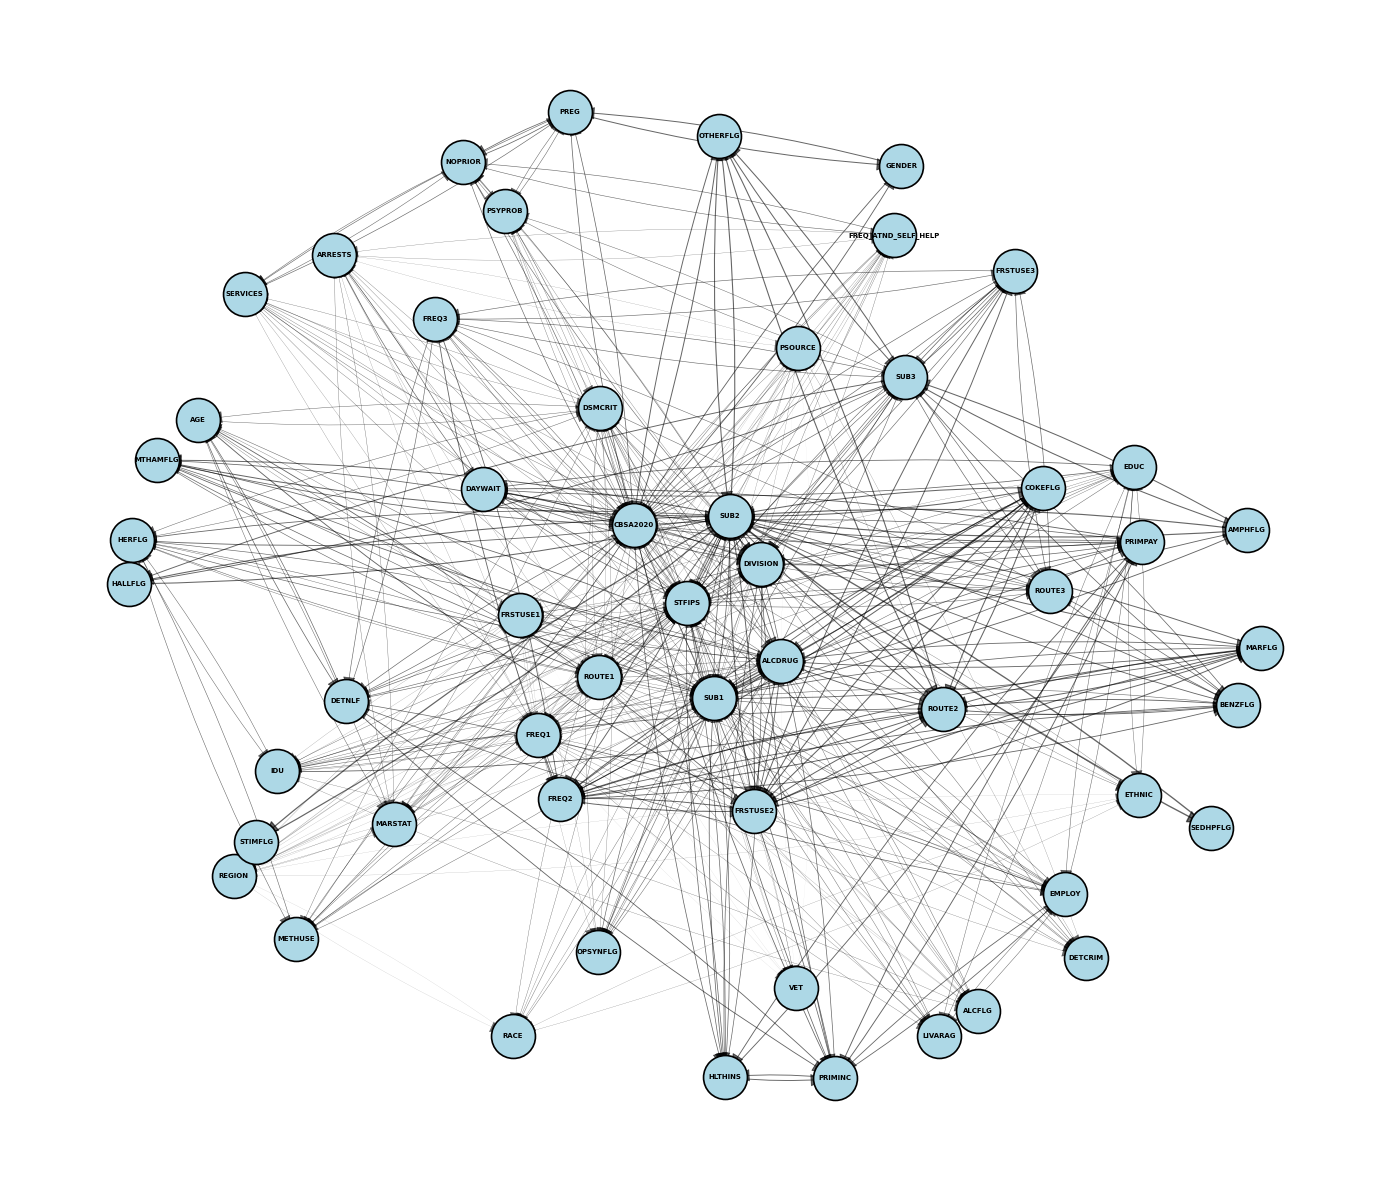

In [99]:
import os
cur_dir = os.getcwd()
edge_importance = os.path.join(cur_dir, '..', 'resources', 'PGExplainer_edge_importance_admission.txt')
draw_star_network(edge_importance)

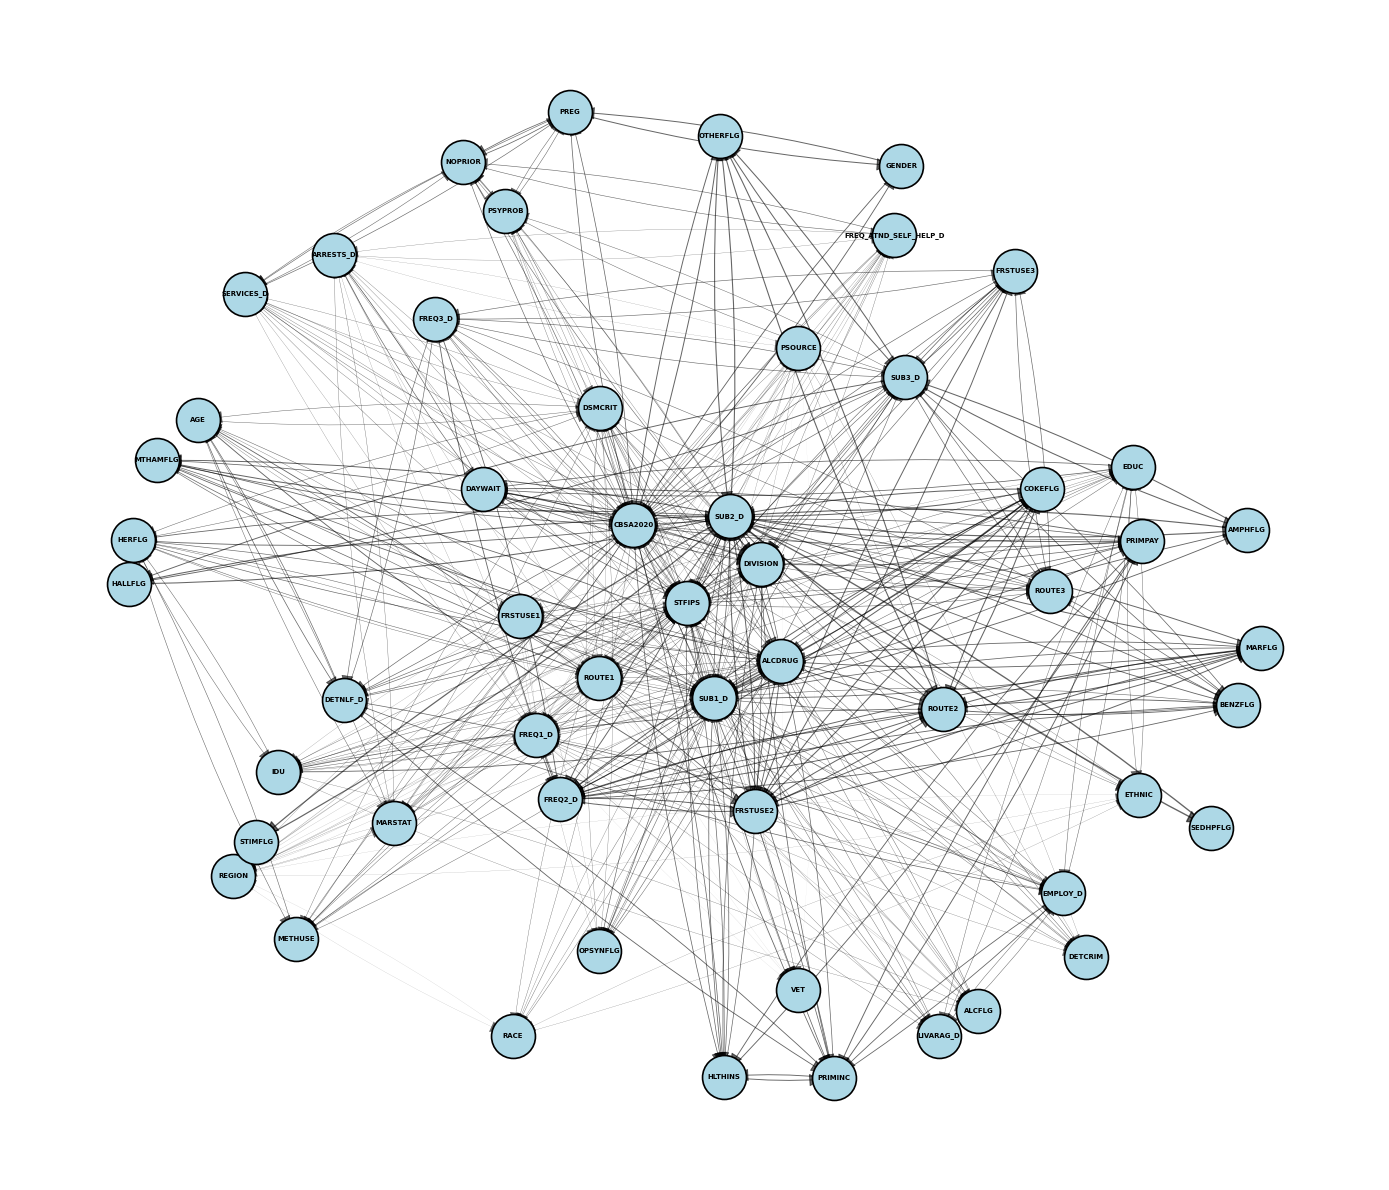

In [100]:
import os
cur_dir = os.getcwd()
edge_importance = os.path.join(cur_dir, '..', 'resources', 'PGExplainer_edge_importance_discharge.txt')
draw_star_network(edge_importance)